In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Linear Congruential Generator (LCG)

This is a  simple way to generate chains of pseudorandom numbers and uniform distributions

A good way to create an LCG is to follow the hull dobell theorem
 ### Hull–Dobell Theorem.

The congruential generator (a,b,M) has period M iff

1. gcd(b,M)=1,

2. p divides a-1 for every prime p that divides M

3. 4 divides a- 1 if 4 divides M.

some good numbers for LCG:

m = 2^31 - 1 = 2147483647

a=16807

c = 0

seed = {1, …, m-1}

Xn+1 = a*Xn mod (2^31 - 1)
IF WE WANT UNIFORM NUMBERS Un = Xn/m


In [ ]:
import numpy as np
def lcg(n, m, a, c, seed=10):
    results = []
    x = seed
    for _ in range(n):
        x = (a * x + c) % m
        results.append(x)
    return np.array(results)

def uniformFromLCG(n,m,a,c,seed):
  return lcg(n,m,a,c,seed) / m

# Inverse Transform Sampling




For an exponential distribution with parameter $\lambda = 1$, the Probability Density Function (PDF) is given by:

$f(x) = e^{-x}$ for $x \ge 0$

The Cumulative Distribution Function (CDF) is found by integrating the PDF:

$F(x) = \int_{0}^{x} e^{-t} dt = [-e^{-t}]_{0}^{x} = -e^{-x} - (-e^{-0}) = 1 - e^{-x}$

To find the Inverse CDF, we set $F(x) = u$, where $u$ is a random variable uniformly distributed between 0 and 1, and solve for $x$:

$u = 1 - e^{-x}$

$e^{-x} = 1 - u$

$-x = \ln(1 - u)$

$x = -\ln(1 - u)$

This formula allows us to generate samples from an exponential distribution using uniform random numbers.

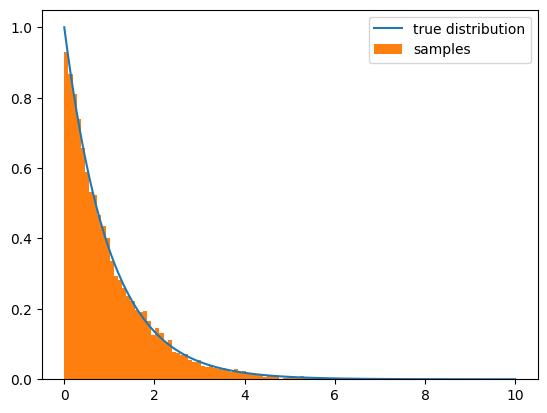

In [ ]:
#exponential distribution with lambda = 1
pdf_x = lambda x: np.exp(-x)
cdf_x = lambda x: 1 - np.exp(-x)
cdf_inverse_x = lambda u: -np.log(1 - u)

Xs = np.linspace(0, 10, num = 1000)
Ys = pdf_x(Xs)

plt.plot(Xs,Ys, label = 'true distribution')  



#Inverse sampling of the distribution
samples = []
for i in range(10000):
  u = np.random.uniform(0,1)
  sample_x = cdf_inverse_x(u)
  samples.append(sample_x)


plt.hist(samples, bins = 100, density= True, label = 'samples')
plt.legend()

# Accept Reject Sampling

We have a pdf of a distribution we want to sample from, but we dont want to use cdf.

1. We get a distribution g that is easy to sample from
2. We pick a constnst M that has the characteristic that f(x) < g(x)*M for every x
3. We pick a u from uniform distribution (0,1)
4. if u <= f(x)/(b*g(x)), we keep the sample, if not, reject
5. Repeat until done


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (2*x*np.exp(x**2))/(np.e-1)

def g(x):
    return 1

M = (2*np.e)/(np.e-1)
def accept_reject(n_samples=1):
    samples = []
    while len(samples) < n_samples:
        x = np.random.uniform(0,1)
        r_x = f(x)/(M*g(x))
        U = np.random.uniform(0,1)
        if U <= r_x:
            samples.append(x)
    return np.array(samples)


In this example, pdf is from 0 to 1, so we pick a uniform distribution from 0 to 1 which has a denstiy g(x), in this case 1. M is a number that guarantees that our f(x) is always smaller than M*g(x)

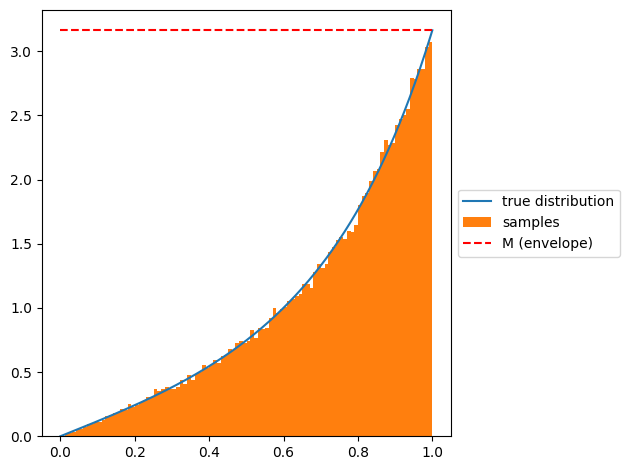

In [ ]:
samples = accept_reject(n_samples = 100000)
Xs = np.linspace(0, 1, num = 1000)
Ys = f(Xs)

plt.plot(Xs,Ys, label = 'true distribution')
plt.hist(samples, density = True, bins = 100, label = 'samples')
plt.hlines(y = M, xmin = 0, xmax = 1, label = 'M (envelope)', color = 'red', linestyles='dashed')
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


# Box-Muller Sampling (Box-Muller Transform)

To generate two independent samples, $Z_0$ and $Z_1$, from a Standard Normal Distribution $N(0, 1)$, follow these steps:

Step 1: Generate Uniform Inputs

Generate two independent random numbers, $U_1$ and $U_2$, from a uniform distribution:$$U_1, U_2 \sim \text{Uniform}(0, 1)$$

Step 2: Apply the Box-Muller Equations

Use the following transformation equations to convert the uniform samples into normal samples:$$Z_0 = \sqrt{-2 \ln U_1} \cos(2\pi U_2)$$$$Z_1 = \sqrt{-2 \ln U_1} \sin(2\pi U_2)$$

Step 3: Adjust for Target Mean ($\mu$) and Variance ($\sigma^2$)

If you need samples from a distribution $N(\mu, \sigma^2)$ rather than the standard $N(0, 1)$, apply the linear transformation:$$X = \mu + Z\sigma$$

Summary of the mapping:

The term $\sqrt{-2 \ln U_1}$ generates the magnitude (radius).The term $2\pi U_2$ generates the angle (0 to 360 degrees).The $\cos$ and $\sin$ functions project that magnitude and angle onto the $X$ and $Y$ axes to produce the final coordinates (samples).

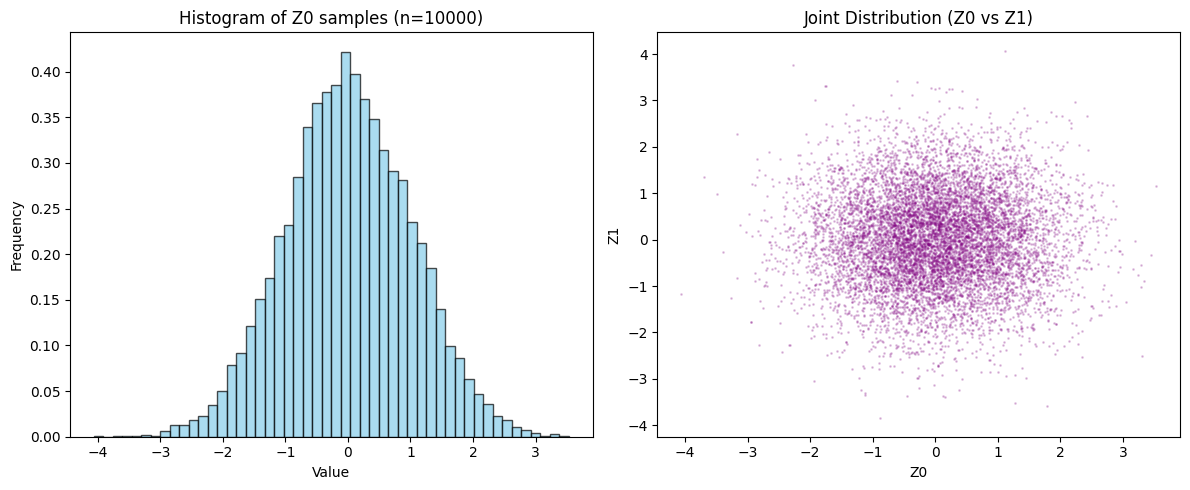

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def box_muller_sample(n_samples, mu=0, sigma=1):
    """
    Generates normal samples using the Box-Muller transform.
    Returns two arrays of independent samples.
    """
    # Step 1: Generate uniform random numbers U1, U2 ~ Uniform(0, 1)
    u1 = np.random.rand(n_samples)
    u2 = np.random.rand(n_samples)

    # Step 2: Apply the transformation equations
    # Magnitude (Radius)
    mag = np.sqrt(-2 * np.log(u1))

    # Angle (0 to 2*pi)
    angle = 2 * np.pi * u2

    # Calculate Z0 and Z1
    z0 = mag * np.cos(angle)
    z1 = mag * np.sin(angle)

    # Step 3: Scale to target mean and standard deviation
    x0 = mu + z0 * sigma
    x1 = mu + z1 * sigma

    return x0, x1

# --- Execution and Visualization ---
n = 10000
samples_x, samples_y = box_muller_sample(n)

# Plotting the results
plt.figure(figsize=(12, 5))

# Plot Histogram to verify Normal Distribution
plt.subplot(1, 2, 1)
plt.hist(samples_x, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f"Histogram of Z0 samples (n={n})")
plt.xlabel("Value")
plt.ylabel("Frequency")

# Plot Scatter to show independence/joint distribution
plt.subplot(1, 2, 2)
plt.scatter(samples_x, samples_y, s=1, alpha=0.2, color='purple')
plt.title("Joint Distribution (Z0 vs Z1)")
plt.xlabel("Z0")
plt.ylabel("Z1")

plt.tight_layout()
plt.show()

# EXERCISES FROM LECTURE NOTES ABOUT GENERATING RVS

(array([ 9929., 10163.,  9857.,  9910.,  9926.,  9969., 10043., 10015.,
        10227.,  9961.]),
 array([7.09202141e-06, 1.00006313e-01, 2.00005533e-01, 3.00004754e-01,
        4.00003974e-01, 5.00003195e-01, 6.00002415e-01, 7.00001636e-01,
        8.00000857e-01, 9.00000077e-01, 9.99999298e-01]),
 <BarContainer object of 10 artists>)

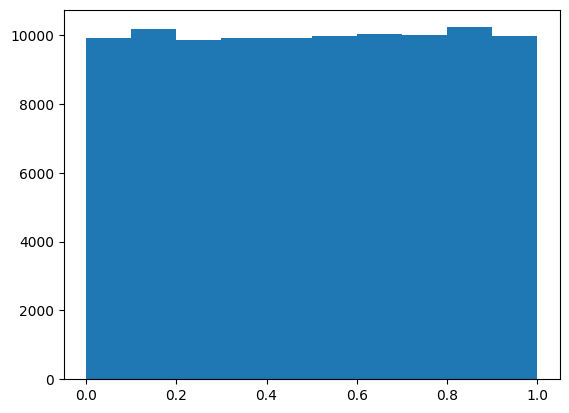

In [ ]:
## 6.19 LCG
import numpy as np
def lcg(n, m, a, c, seed=10):
    results = []
    x = seed
    for _ in range(n):
        x = (a * x + c) % m
        results.append(x)
    return np.array(results)

def uniformFromLCG(n,m,a,c,seed):
  return lcg(n,m,a,c,seed) / m

samples = uniformFromLCG(n=100000,m=2147483647,a=16807, c=0, seed = 13)

plt.hist(samples)

In [ ]:
import numpy as np
from math import sqrt, log

def ks_distance_to_uniform(u):
    """
    D_n = sup_x |F_n(x) - x| for Uniform(0,1).
    Computes the exact sup over points induced by the sample.
    """
    u = np.asarray(u, dtype=np.float64)
    if np.any(u < 0) or np.any(u >= 1):
        raise ValueError("Samples must be in [0,1).")

    x = np.sort(u)
    n = x.size
    i = np.arange(1, n + 1)

    # For continuous F, the two one-sided KS components are:
    # D+ = max_i (i/n - x_i)
    # D- = max_i (x_i - (i-1)/n)
    d_plus = np.max(i / n - x)
    d_minus = np.max(x - (i - 1) / n)
    return float(max(d_plus, d_minus))

def dkw_threshold(n, alpha=0.05):
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0,1).")
    return sqrt(log(2.0 / alpha) / (2.0 * n))

def dkw_uniformity_test(u, alpha=0.05):
    n = len(u)
    Dn = ks_distance_to_uniform(u)
    eps = dkw_threshold(n, alpha)
    return {
        "n": n,
        "alpha": alpha,
        "Dn": Dn,
        "threshold_eps": eps,
        "pass": Dn <= eps
    }


In [ ]:
# 6.20

def boxMuller(n):
  u1 = uniformFromLCG(n=n,m=2147483647,a=16807, c=0, seed = 13)
  u2 = uniformFromLCG(n=n,m=2147483647,a=16807, c=0, seed = 2137)
  mag = np.sqrt(-2 * np.log(u1))

  # Angle (0 to 2*pi)
  angle = 2 * np.pi * u2

  # Calculate Z0 and Z1
  z0 = mag * np.cos(angle)
  z1 = mag * np.sin(angle)

  # Step 3: Scale to target mean and standard deviation
  x0 = 10 + z0 * 5
  x1 = 10 + z1 * 5

  return x0, x1

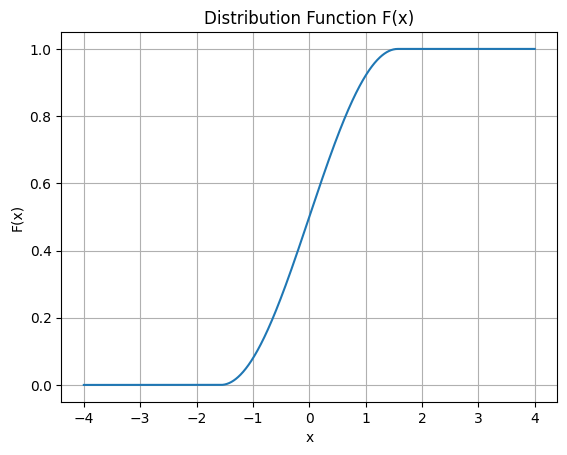

In [ ]:
# 6.21

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 1000)
F = np.zeros_like(x)

a, b = -np.pi/2, np.pi/2

mid = (x > a) & (x < b)
F[mid] = 0.5 * (np.sin(x[mid]) + 1)
F[x >= b] = 1.0

plt.plot(x, F)
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Distribution Function F(x)")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.show()

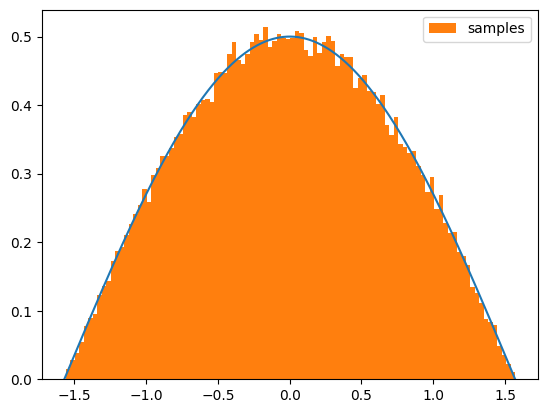

In [ ]:
# Inverse
inverse_f = lambda u: np.arcsin(2*u - 1)
pdf = lambda x: 0.5 * np.cos(x)

Xs = np.linspace(-np.pi/2, np.pi/2, 1000)
Ys = pdf(Xs)

plt.plot(Xs,Ys)

samples = []
for i in range(100000):
  u = np.random.uniform(0,1)
  sample_x = inverse_f(u)
  samples.append(sample_x)


plt.hist(samples, bins = 100, density= True, label = 'samples')
plt.legend()

(array([0.00861252, 0.02360468, 0.03317414, 0.0555029 , 0.06698625,
        0.08070249, 0.10526411, 0.1215322 , 0.12854981, 0.15247347,
        0.15693922, 0.17129342, 0.19202726, 0.20287265, 0.21499398,
        0.23190003, 0.22615835, 0.26252232, 0.27655753, 0.30048119,
        0.31930114, 0.30494694, 0.33684516, 0.31898216, 0.33269839,
        0.35438918, 0.36491559, 0.3843735 , 0.36140679, 0.39234806,
        0.39649482, 0.41403884, 0.42520322, 0.44179029, 0.42137543,
        0.44242825, 0.45518754, 0.46348108, 0.47432647, 0.48549085,
        0.47783527, 0.47974917, 0.48708576, 0.49984504, 0.50271588,
        0.49187049, 0.49027558, 0.49984504, 0.47273156, 0.50431079,
        0.50622469, 0.50271588, 0.49856911, 0.47687833, 0.49856911,
        0.47751629, 0.51228535, 0.49218947, 0.48708576, 0.46188617,
        0.47305054, 0.47687833, 0.45391161, 0.46730886, 0.46475701,
        0.45869634, 0.41403884, 0.42839304, 0.41722866, 0.42488424,
        0.3987277 , 0.39426195, 0.38150266, 0.37

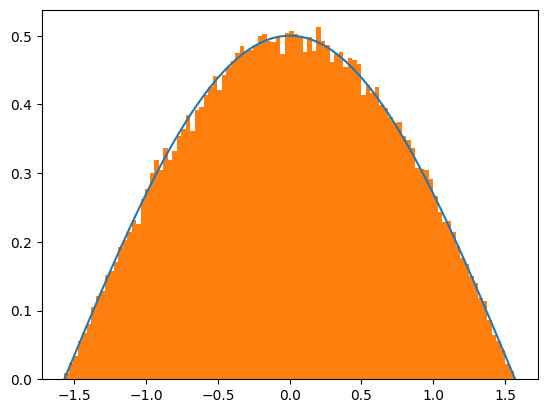

In [ ]:
# Accept Reject

def f(x):
    return 0.5 * np.cos(x)

def g(x):
    return 1/np.pi

M = np.pi/2
def accept_reject(n_samples=1):
    samples = []
    while len(samples) < n_samples:
        x = np.random.uniform(-np.pi/2,np.pi/2)
        r_x = f(x)/(M*g(x))
        U = np.random.uniform(0,1)
        if U <= r_x:
            samples.append(x)
    return np.array(samples)


samples = accept_reject(n_samples = 100000)
plt.plot(Xs,Ys)
plt.hist(samples, density = True,bins = 100)

# Markov Chains



## Irreducible markov chains

 A Markov chain is irreducible if every state can reach every other state with positive probability in some finite number of steps.

 #### **In other words, you can reach every state from every other state.**


 #### **To check if a markov chain is irreducible, you can convert it to a graph and check if it is strongly connected**

In [ ]:
#CODE FOR CHECKING IF MARKOV CHAIN IS IRREDUCIBLE
import numpy as np
import networkx as nx


#this code works by converting the markov chain into graph and checking if it's strongly connected
def is_reducible(P):
    G = nx.DiGraph()
    n = P.shape[0]

    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(i, j)

    return not nx.is_strongly_connected(G)

# print(is_reducible(P))

## Aperiodic markov chains

A chain is aperiodic if the gcd of going back to a state from other states is 1, so you can reach a state in any multiplicity of steps, like 1,2,3,4,5,6. A chain is periodic, if you can only reach a state in some multiple of steps (0,2,4,6….) or (3,6,9,...).

1. **Chain irreducible —> every state the same periodicity (1 or more)**
2. **If chain has a loop on the same state —> aperiodic z bomby**


In [ ]:
#CODE FOR CHECKING IF MARKOV CHAIN IS APERIODIC (MIGHT NOT WORK PROPERLY!!!!!!!)

import numpy as np
from math import gcd
from functools import reduce

def state_period(P, i, max_power=50, tol=1e-12):
    n = P.shape[0]
    Pn = np.eye(n)
    return_times = []

    for k in range(1, max_power + 1):
        Pn = Pn @ P
        if Pn[i, i] > tol:
            return_times.append(k)

    if not return_times:
        return None  # should not happen in finite irreducible chains

    return reduce(gcd, return_times)

def is_aperiodic(P):
    n = P.shape[0]
    periods = [state_period(P, i) for i in range(n)]
    return all(p == 1 for p in periods)


## Stationary distributions of markov chains


If the Markov chain has a finite amount of states → always exists.

formally it’s a solution to πP = π, where P is the transition matrix and π is the vector of stationary states of length of the number of states. We get a system of equations, but we have to add normalization equation,

π1 + π2 + … πn = 1
so all the probs add up to 1.


In [ ]:
# CALCULATING STATIONARY DISTRIBUTION


#Solving the stationary distribution linear equation system and printing the solution
def stationary_distribution(P):
    n = P.shape[0]

    A = np.vstack([
        P.T - np.eye(n),
        np.ones(n)
    ])
    b = np.zeros(n + 1)
    b[-1] = 1

    # Least-squares solve (robust to rank deficiency)
    pi, *_ = np.linalg.lstsq(A, b, rcond=None)
    return pi


## Reversible markov chains

A Markov chain is reversible if, in stationarity, the process looks the same forward and backward in time.
to check if a markov chain is reversible, you check if

$π_a * P_{ab} = π_b*P_{ba}$

You do that for every step. If every of them matches, it's reversible. if even one fails, its not

In [ ]:
#CODE FOR CHECKING REVERSIBILITY

#This code literally checks this for every state in the stationary distribution
def is_reversible(P, tol=1e-10):
    pi = stationary_distribution(P)
    n = P.shape[0]

    for i in range(n):
        for j in range(n):
            if abs(pi[i] * P[i, j] - pi[j] * P[j, i]) > tol:
                return False
    return True

In [ ]:
#Example usage of the code

#Transition matrix of an exemplary markov chain (from mock exam, example 1)
P = np.array([[0.8,0.2,0,0],[0.6,0.2,0.2,0],[0,0.4,0,0.6],[0,0,0.8,0.2]])

print(is_reducible(P))
print(is_aperiodic(P))
print(stationary_distribution(P))
print(is_reversible(P))

False
True
[0.61538462 0.20512821 0.1025641  0.07692308]
True
